### 3. Selección de métricas  

En este apartado nos centraremos en las métricas de clasificación.

Para comenzar, entrenar una **regressió logística**. A partir de esta, generar una serie de funciones para analizar los resultados.  

También se ha de elegir la métrica que se hará servir posteriormente para escoger el mejor modelo.  

**Preguntas:**  
-  ¿Cuál de las siguientes métricas se cree que es más adecuada para el problema? Justifíca. 
   - `accuracy_score`  
   - `f1_score`  
   - `average_precision_score`  
-  Antes de entrenar modelos, generar una suite de funciones para analizar gráficamente el rendimiento. 
   -  Mostrar la *Precision-Recall Curve* y la *ROC Curve*.  
   -  ¿Cuál es más relevante para su dataset? 
   -  Explicar con sus palabras la diferencia entre ambas.
-  Que muestra el [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)?  
   -  ¿Qué métrica elegirá para optimizar la clasificación en su caso?




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, average_precision_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc 
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns 

Accuracy: 0.6714285714285714
F1 Score (macro): 0.6822449108944678
Average Precision (macro): 0.7650715672850547

REPORT DE CLASSIFICACIÓ DETALLAT:
                   precision    recall  f1-score   support

    deforestacion       0.64      0.36      0.46        64
   enfermo_estres       0.73      0.84      0.78        63
    enfermo_plaga       0.57      0.51      0.54       122
   enfermo_sequia       0.84      0.61      0.71       125
estres_inundacion       0.93      0.82      0.88        34
         incendio       0.52      0.81      0.63       148
             sano       0.82      0.75      0.78       144

         accuracy                           0.67       700
        macro avg       0.72      0.67      0.68       700
     weighted avg       0.70      0.67      0.67       700



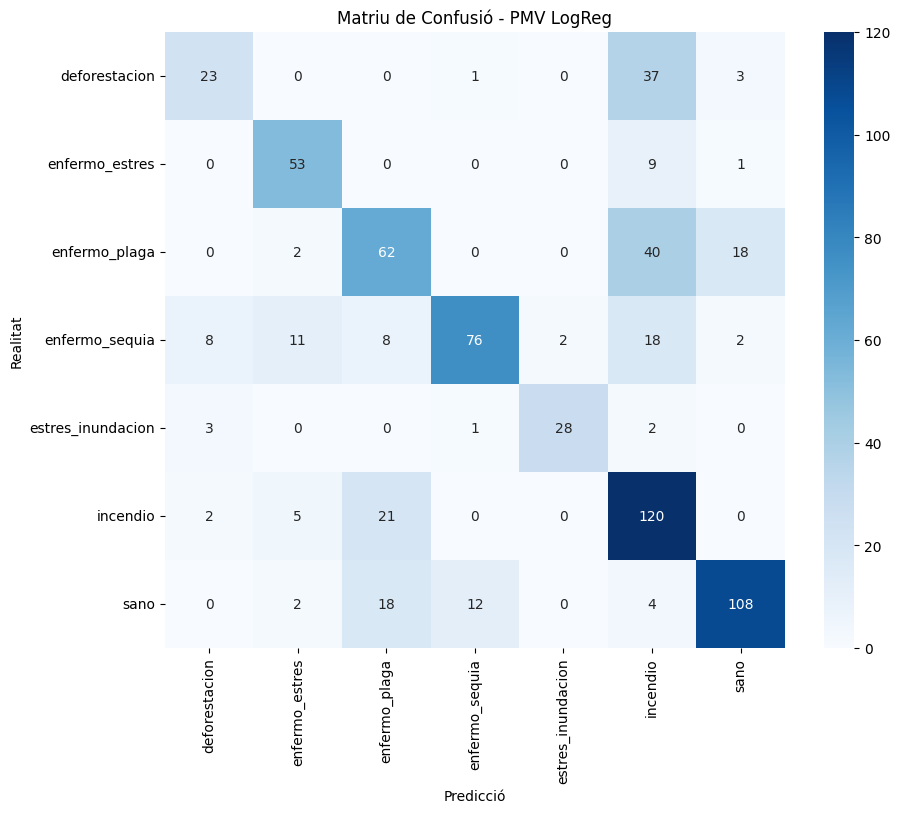

In [2]:
#Carregar el Dataset
df = pd.read_csv('../data/dataset.csv')
X = df.select_dtypes(include=['number']).copy()
X = X.fillna(X.median())
y = df['estado']  
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)
 
y_pred = logreg.predict(x_test)
y_scores = logreg.predict_proba(x_test)
 
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
ap = average_precision_score(y_test, y_scores, average='macro')
 
print("Accuracy:", acc)
print("F1 Score (macro):", f1)
print("Average Precision (macro):", ap)

print("\nREPORT DE CLASSIFICACIÓ DETALLAT:")
print(classification_report(y_test, y_pred))

#Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=logreg.classes_, 
            yticklabels=logreg.classes_)
plt.title('Matriu de Confusió - PMV LogReg')
plt.xlabel('Predicció')
plt.ylabel('Realitat')
plt.show()

### 4. Selección de modelos con validación cruzada  

Haciendo servir la métrica seleccionada del apartado anterior, seleccionar el mejor model con sus hiperparámetros óptimos, encontrado a través de una búsqueda (*hyperparameter search*) en los siguientes modelos:  
  
- Regressió logística  
- SVM  
- Hist Gradient Boosting  
- Random Forest   

**Preguntas:**  
-  ¿Por qué se ha seleccionado estos modelos?  
-  Haciendo servir validación cruzada, escoger el mejor modelo (con hiperparámetros por defecto).  
   -  ¿Por qué es importante hacer sevir validación cruzada?  
   -  ¿Se ha de hacer servir un tipo especifico de validación cruzada?  
-  Seleccionar un conjunto de **hiperparámetros** a probar para cada modelo y realizar la búsqueda corresponiente.  
   -  ¿Hay algún modelo que se pueda descartar de primeras? ¿Por qué?  
-  Mostrar los resultados en una tabla con: modelo, experimentos realizados, resultados (train i test) y tiempo de entrenamiento.  